
# Platform‑Specific Pricing & Discount Behavior
Steam vs Epic • Indie vs Non‑Indie

This notebook analyzes **pricing** and **discount behavior** across platforms using your curated gold‑layer datasets:
- **Price distributions** (Steam vs Epic) for **Indie** and **Non‑Indie**
- **Discount distributions** (Steam vs Epic) for **Indie** and **Non‑Indie**
- **Cross‑platform gaps** (Steam − Epic) for price and discount
- **Summary tables** you can paste into the report


In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Load & Prepare Data

In [2]:
indie_path = '../data/gold/indie.csv'
notindie_path = '../data/gold/notindie.csv'

In [3]:
pd.set_option("display.max_colwidth", 120)

def to_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def parse_list_like(df, col, new_col):
    if col not in df.columns:
        df[new_col] = [[] for _ in range(len(df))]
        return df
    def _safe(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else (x if isinstance(x, list) else [])
        except Exception:
            return []
    df[new_col] = df[col].apply(_safe)
    return df

def quick_stats(name, df):
    out = {
        "rows": len(df),
        "steam_price_mean": df["price_steam"].mean(),
        "steam_price_median": df["price_steam"].median(),
        "steam_price_std": df["price_steam"].std(),
        "epic_price_mean": df["price_epic"].mean(),
        "epic_price_median": df["price_epic"].median(),
        "epic_price_std": df["price_epic"].std(),
        "steam_disc_mean": df["discount_percent_steam"].mean(),
        "steam_disc_median": df["discount_percent_steam"].median(),
        "epic_disc_mean": df["discount_percent_epic"].mean(),
        "epic_disc_median": df["discount_percent_epic"].median(),
    }
    return pd.Series(out, name=name).round(3)

## Load Data

In [4]:
indie = pd.read_csv(indie_path)
notindie = pd.read_csv(notindie_path)

numeric_cols = ["price_steam","price_epic","discount_percent_steam","discount_percent_epic"]
indie = to_numeric(indie, numeric_cols)
notindie = to_numeric(notindie, numeric_cols)

# Optional: parse platforms if needed later
indie = parse_list_like(indie, "platform", "platform_list")
notindie = parse_list_like(notindie, "platform", "platform_list")

print("Indie shape:", indie.shape, " | Not-Indie shape:", notindie.shape)

Indie shape: (91916, 21)  | Not-Indie shape: (59293, 21)


## Summary Statistics

In [5]:

summary = pd.concat([quick_stats("indie", indie), quick_stats("notindie", notindie)], axis=1)
summary

,indie,notindie
rows,91916.000,59293.000
steam_price_mean,8.537,18.635
steam_price_median,4.620,7.470
steam_price_std,67.566,198.770
epic_price_mean,15.537,20.424
epic_price_median,14.990,14.990
epic_price_std,8.946,22.596
steam_disc_mean,4.348,4.305
steam_disc_median,0.000,0.000
epic_disc_mean,0.152,0.173


## Price Comparison

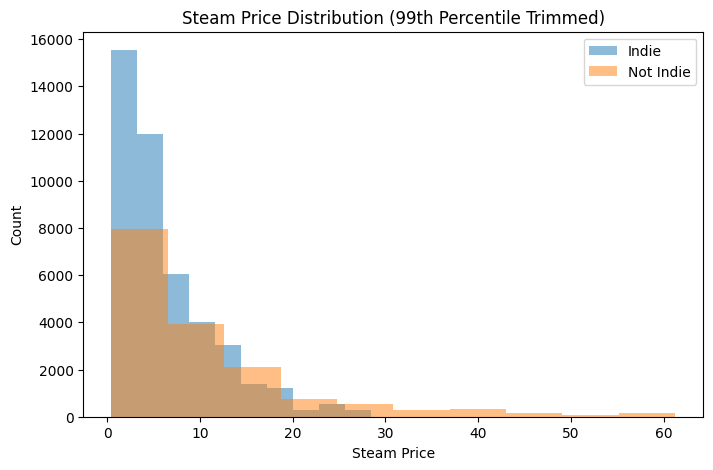

In [6]:
# Histogram: Steam prices (Indie vs Not Indie)
indie_filtered = indie[indie["price_steam"] <= indie["price_steam"].quantile(0.99)]
not_filtered = notindie[notindie["price_steam"] <= notindie["price_steam"].quantile(0.99)]

plt.figure(figsize=(8,5))
plt.hist(indie_filtered["price_steam"], bins=10, alpha=0.5, label="Indie")
plt.hist(not_filtered["price_steam"], bins=10, alpha=0.5, label="Not Indie")
plt.xlabel("Steam Price")
plt.ylabel("Count")
plt.title("Steam Price Distribution (99th Percentile Trimmed)")
plt.legend()
plt.show()

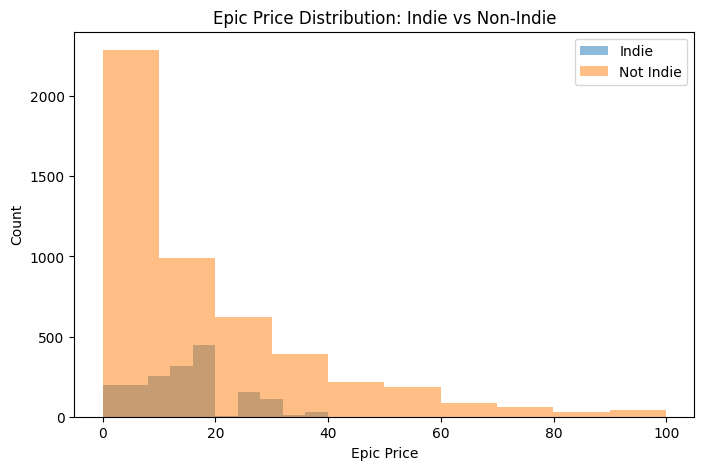

In [7]:

# Histogram: Epic prices (Indie vs Not Indie)
indie_filtered_epic = indie[indie["price_epic"] <= indie["price_epic"].quantile(0.99)]
not_filtered_epic = notindie[notindie["price_epic"] <= notindie["price_epic"].quantile(0.99)]

plt.figure(figsize=(8,5))
plt.hist(indie_filtered_epic["price_epic"].dropna(), bins=10, alpha=0.5, label="Indie")
plt.hist(not_filtered_epic["price_epic"].dropna(), bins=10, alpha=0.5, label="Not Indie")
plt.xlabel("Epic Price")
plt.ylabel("Count")
plt.title("Epic Price Distribution: Indie vs Non-Indie")
plt.legend()
plt.show()

C:\Users\yuzhu\AppData\Local\Temp\ipykernel_8788\1460526403.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Indie","Not Indie"], showmeans=True)


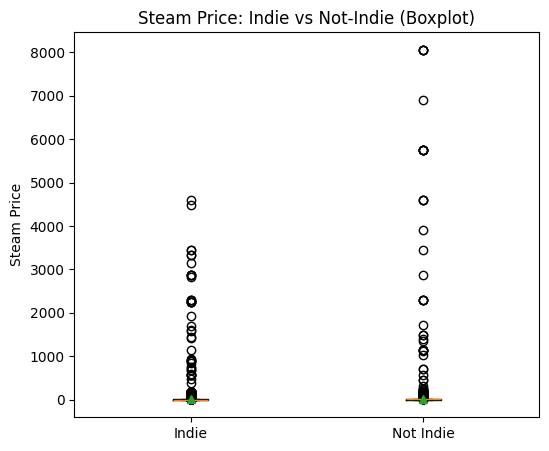

In [8]:

# Boxplots: Steam price comparison
plt.figure(figsize=(6,5))
data = [indie["price_steam"].dropna(), notindie["price_steam"].dropna()]
plt.boxplot(data, labels=["Indie","Not Indie"], showmeans=True)
plt.ylabel("Steam Price")
plt.title("Steam Price: Indie vs Not-Indie (Boxplot)")
plt.show()

C:\Users\yuzhu\AppData\Local\Temp\ipykernel_8788\13868174.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Indie","Not Indie"], showmeans=True)


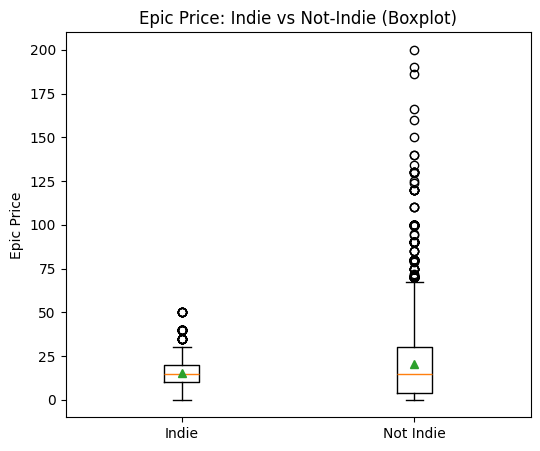

In [9]:
# Boxplots: Epic price comparison
plt.figure(figsize=(6,5))
data = [indie["price_epic"].dropna(), notindie["price_epic"].dropna()]
plt.boxplot(data, labels=["Indie","Not Indie"], showmeans=True)
plt.ylabel("Epic Price")
plt.title("Epic Price: Indie vs Not-Indie (Boxplot)")
plt.show()

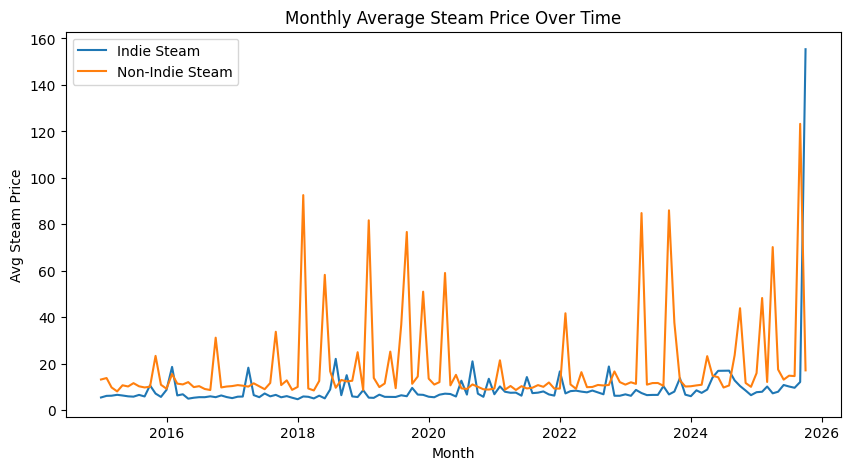

In [ ]:
# Convert effective dates
for df in [indie, notindie]:
    for col in ["effective_date_steam","effective_date_epic"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
            
            
indie_steam_month = indie.set_index("effective_date_steam")["price_steam"].resample("MS").mean()
not_steam_month = notindie.set_index("effective_date_steam")["price_steam"].resample("MS").mean()

plt.figure(figsize=(10,5))
plt.plot(indie_steam_month.index, indie_steam_month.values, label="Indie Steam")
plt.plot(not_steam_month.index, not_steam_month.values, label="Non‑Indie Steam")
plt.xlabel("Month")
plt.ylabel("Avg Steam Price")
plt.title("Monthly Average Steam Price Over Time")
plt.legend()
plt.show()

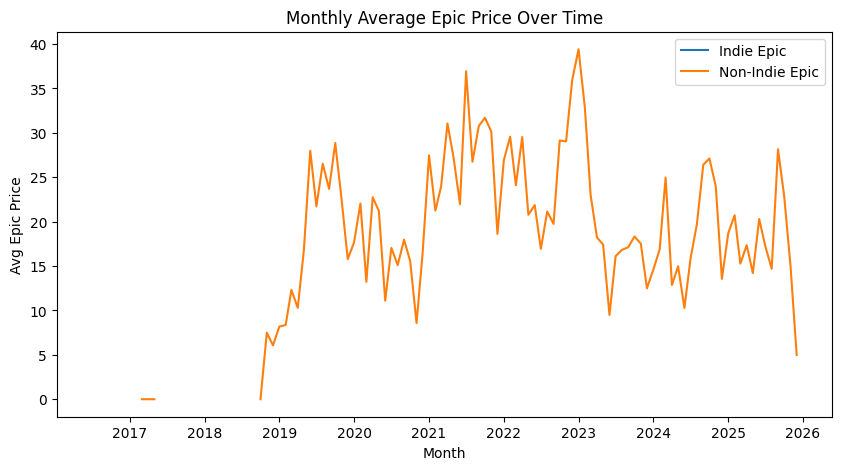

In [ ]:
indie["effective_date_epic"] = pd.to_datetime(indie["effective_date_epic"], errors="coerce")
m_indie = (
    indie.dropna(subset=["effective_date_epic"])
         .assign(month=lambda d: d["effective_date_epic"].dt.to_period("M"))
         .groupby("month")["price_epic"].mean()
         .sort_index()
)

indie_epic_month = m_indie.index.to_timestamp()
indie_epic_month = pd.Series(m_indie.values, index=indie_epic_month)
not_epic_month = notindie.set_index("effective_date_epic")["price_epic"].resample("MS").mean()

plt.figure(figsize=(10,5))
plt.plot(indie_epic_month.index, indie_epic_month.values, label="Indie Epic")
plt.plot(not_epic_month.index, not_epic_month.values, label="Non‑Indie Epic")
plt.xlabel("Month")
plt.ylabel("Avg Epic Price")
plt.title("Monthly Average Epic Price Over Time")
plt.legend()
plt.show()